## Running example from the readme


In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
def corrupt_by_dim(X):
    """
    Corrupt by taking away some dimensions fully
    """
    X_corr = np.copy(X)
    T, n_dims = X.shape[1], X.shape[2]
    for x in X_corr:
        nb_obs_vals = np.random.randint(0,5)
        obs_mask = np.random.choice(np.arange(T), size = T - nb_obs_vals, replace = False)
        obs_mask = np.isin(np.arange(T), obs_mask)
        n_dims_missing = np.random.randint(1,4)
        dims = np.random.choice(np.arange(n_dims), size = n_dims_missing, replace = False)
        for dim in dims:
            x[obs_mask,dim] = np.nan

    return X_corr

In [233]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

def generate_gp_samples_with_library(n_groups, n_observations_per_group, n_dimensions, time_points, length_scale=1.0):
    """
    Generate multidimensional GP samples using scikit-learn.
    Each dimension has the same underlying process.
    """
    kernel = RBF(length_scale=length_scale)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-8)

    gp_sample_constant = gp.sample_y(time_points.reshape(-1, 1), random_state=None).flatten()

    samples = []
    for _ in range(n_groups):
        group_samples = []
        for _ in tqdm(range(n_observations_per_group)):
            # Generate independent samples for each dimension
            gp_samples_per_dim = []
            for _ in range(n_dimensions):
                gp_sample = gp.sample_y(time_points.reshape(-1, 1), random_state=None).flatten()
                gp_samples_per_dim.append(gp_sample)
            # Stack the samples to form a multidimensional sample
            gp_samples_multidim = np.stack(gp_samples_per_dim, axis=-1)
            group_samples.append(gp_samples_multidim)
        samples.append(np.array(group_samples))

    return samples

def Generate_samples(n_groups=1, n_observations_per_group=5000, n_dimensions=30, n_time_points=30,
                     time_points=np.linspace(0, 10, 30), length_scale=1.5, n_new_dims=7):
    """Generate synthetic dataset with Gaussian Process and structured missingness."""
    
    gp_samples = generate_gp_samples_with_library(
        n_groups=n_groups, n_observations_per_group=n_observations_per_group,
        n_dimensions=n_dimensions, time_points=time_points, length_scale=length_scale
    )

    Proj = np.random.uniform(size=(n_dimensions, n_new_dims))
    X_ori = gp_samples[0] @ Proj

    X_normalized = (X_ori - X_ori.mean(axis=(0, 1)).reshape(1, 1, -1)) / X_ori.std(axis=(0, 1)).reshape(1, 1, -1)
    #X = corrupt_by_dim(X_normalized.copy())
    return X_normalized

def generate_missingness(X, p_dataset = .1):

    X = corrupt_by_dim(X_normalized.copy())
    #X = mcar(X.copy(), p_dataset)  # randomly hold out 10% observed values as ground truth
    X[np.isnan(X)] = 0  # Replace NaNs with zeros

    dataset = {'X': X}
    len_dataset = len(dataset['X'])
    cut = int(len_dataset * 0.7)
    dataset_train, dataset_val = {'X': dataset['X'][:cut]}, {'X': dataset['X'][cut:], 'X_ori': X_normalized[cut:]}

    return X, dataset_train, dataset_val

## Generate latent time series of size n_dimensions

In [238]:
X_normalized = Generate_samples(n_observations_per_group = 1000)
X, dataset_train, dataset_val = generate_missingness(X_normalized, p_dataset = .5)

100%|██████████████████████████████████████| 1000/1000 [00:05<00:00, 195.81it/s]


In [190]:
#X, X_normalized, dataset_train, dataset_val = Generate_samples(n_observations_per_group = 50, 
#                                                               p_dataset = .3)

100%|██████████████████████████████████████████| 50/50 [00:00<00:00, 233.39it/s]


## Project this time series into a random space of size n_new_dims

In [239]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GP_VAE_posterior_concistency
from pypots.utils.metrics import calc_mae
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

latent_size = 15
    
gpvae = GP_VAE_posterior_concistency(n_steps = dataset['X'].shape[1], 
            n_features = dataset['X'].shape[2], 
            latent_size = latent_size, #desired latent size, chosen as bigger thant the actual latent space of size 10
            epochs = 300, 
            batch_size = 64,
            beta = 1., #beta weight which is redefined underneath for clarity
            K = 3,  # number of samples from the latent distribution 
            encoder_sizes = (128,64,32), 
            decoder_sizes = (64,32),
            optimizer = Adam() #lr = 1e-4
            )

from pypots.imputation.gp_ae.gp_model import ProbabilisticGP
gpvae.model.backbone.gp = ProbabilisticGP(gpvae.model.backbone, assemble_data = gpvae._assemble_input_for_training, n_dims = n_new_dims, latent_size = latent_size)


gpvae.model.backbone.alpha = 1e-1   # weight of KL between q(z|x_observed) et q(z|x_observed_corrompu)
gpvae.model.backbone.beta = 1e0       # weight of prior on latent space (c'est juste une regularisation, je force l'espace latent a etre centré en 0)
gpvae.model.backbone.gamma = 1e-5   # weight of time coherence loss (2 consecutive latent observations z_t and z_{t+1} must be close modulo
                                    # the difference between the observed data X_t and X_{t+1} and the latent variance
gpvae.model.backbone.sampling = True # wether or not we add a sampling scheme to approximate x_missing|x_observed to force
                                     # encode the imputed sample x_sampled = (x_missing|x_observed, x_observed) such that
                                     # q(z|x_sampled) to be included in q(z|x_observed)

#with torch.autograd.set_detect_anomaly(False):
gpvae.model.backbone.device = 'cpu'

#with torch.autograd.set_detect_anomaly(True):
gpvae.fit(dataset_train)  # train the model on the dataset

2025-01-31 18:53:10 [INFO]: No given device, using default device: cpu
2025-01-31 18:53:10 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-01-31 18:53:10 [INFO]: GP_VAE_posterior_concistency initialized with the given hyperparameters, the number of trainable parameters: 16,581


Model dimensions is: 
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=14, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
  )
  (mu_layer): Linear(in_features=32, out_features=15, bias=True)
  (logvar_layer): Linear(in_features=32, out_features=15, bias=True)
)
GpvaeDecoder(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)


2025-01-31 18:53:11 [INFO]: Epoch 001 - training loss: 27.2012


-23.85736656188965 -12.111285209655762 0.005518099293112755 -11.7611665725708


2025-01-31 18:53:12 [INFO]: Epoch 002 - training loss: 26.6951
2025-01-31 18:53:12 [INFO]: Epoch 003 - training loss: 23.4340
2025-01-31 18:53:13 [INFO]: Epoch 004 - training loss: 13.2983
2025-01-31 18:53:14 [INFO]: Epoch 005 - training loss: 8.5905
2025-01-31 18:53:15 [INFO]: Epoch 006 - training loss: 7.3497
2025-01-31 18:53:15 [INFO]: Epoch 007 - training loss: 6.7207


...

2025-01-31 18:55:45 [INFO]: Epoch 262 - training loss: 0.3787
2025-01-31 18:55:45 [INFO]: Epoch 263 - training loss: 0.3780
2025-01-31 18:55:46 [INFO]: Epoch 264 - training loss: 0.3750
2025-01-31 18:55:46 [INFO]: Epoch 265 - training loss: 0.3937
2025-01-31 18:55:47 [INFO]: Epoch 266 - training loss: 0.4000
2025-01-31 18:55:47 [INFO]: Epoch 267 - training loss: 0.3724
2025-01-31 18:55:47 [INFO]: Epoch 268 - training loss: 0.3717
2025-01-31 18:55:48 [INFO]: Epoch 269 - training loss: 0.3756
2025-01-31 18:55:48 [INFO]: Epoch 270 - training loss: 0.3688
2025-01-31 18:55:49 [INFO]: Epoch 271 - training loss: 0.3700
2025-01-31 18:55:49 [INFO]: Epoch 272 - training loss: 0.3684
2025-01-31 18:55:50 [INFO]: Epoch 273 - training loss: 0.3653
2025-01-31 18:55:50 [INFO]: Epoch 274 - training loss: 0.3626
2025-01-31 18:55:51 [INFO]: Epoch 275 - training loss: 0.3613
2025-01-31 18:55:51 [INFO]: Epoch 276 - training loss: 0.3647
2025-01-31 18:55:51 [INFO]: Epoch 277 - training loss: 0.3754
2025-01-

0.1990131139755249 -0.23137322068214417 5.497980117797852 0.40198183059692383


2025-01-31 18:56:01 [INFO]: Epoch 298 - training loss: 0.3444
2025-01-31 18:56:01 [INFO]: Epoch 299 - training loss: 0.3509


0.19536089897155762 -0.23806005716323853 5.193867206573486 0.3987657427787781


2025-01-31 18:56:02 [INFO]: Epoch 300 - training loss: 0.3564
2025-01-31 18:56:02 [INFO]: Finished training. The best model is from epoch#298.


In [240]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GP_VAE
from pypots.utils.metrics import calc_mae
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

latent_size = 15
    
gpvae2 = GP_VAE(n_steps = dataset['X'].shape[1], 
            n_features = dataset['X'].shape[2], 
            latent_size = latent_size, #desired latent size, chosen as bigger thant the actual latent space of size 10
            epochs = 300, 
            batch_size = 64,
            beta = 1., #beta weight which is redefined underneath for clarity
            K = 3,  # number of samples from the latent distribution 
            encoder_sizes = (128,64,32), 
            decoder_sizes = (64,32),
            optimizer = Adam() #lr = 1e-4
            )

from pypots.imputation.gp_ae.gp_model import ProbabilisticGP
gpvae2.model.backbone.gp = ProbabilisticGP(gpvae.model.backbone, assemble_data = gpvae._assemble_input_for_training, n_dims = n_new_dims, latent_size = latent_size)


gpvae2.model.backbone.alpha = 1e0   # weight of KL between q(z|x_observed) et q(z|x_observed_corrompu)
gpvae2.model.backbone.beta = 1e1       # weight of prior on latent space (c'est juste une regularisation, je force l'espace latent a etre centré en 0)
gpvae2.model.backbone.gamma = 1e-5   # weight of time coherence loss (2 consecutive latent observations z_t and z_{t+1} must be close modulo
                                    # the difference between the observed data X_t and X_{t+1} and the latent variance
gpvae2.model.backbone.sampling = True # wether or not we add a sampling scheme to approximate x_missing|x_observed to force
                                     # encode the imputed sample x_sampled = (x_missing|x_observed, x_observed) such that
                                     # q(z|x_sampled) to be included in q(z|x_observed)

#with torch.autograd.set_detect_anomaly(False):
gpvae2.model.backbone.device = 'cpu'

#with torch.autograd.set_detect_anomaly(True):
gpvae2.fit(dataset_train)  # train the model on the dataset

2025-01-31 18:56:02 [INFO]: No given device, using default device: cpu
2025-01-31 18:56:02 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-01-31 18:56:02 [INFO]: GP_VAE initialized with the given hyperparameters, the number of trainable parameters: 16,581


Model dimensions is: 
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=14, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
  )
  (mu_layer): Linear(in_features=32, out_features=15, bias=True)
  (logvar_layer): Linear(in_features=32, out_features=15, bias=True)
)
GpvaeDecoder(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)


2025-01-31 18:56:02 [INFO]: Epoch 001 - training loss: 56.1912
2025-01-31 18:56:02 [INFO]: Epoch 002 - training loss: 54.5006
2025-01-31 18:56:02 [INFO]: Epoch 003 - training loss: 47.6139
2025-01-31 18:56:02 [INFO]: Epoch 004 - training loss: 27.9530
2025-01-31 18:56:03 [INFO]: Epoch 005 - training loss: 18.0339
2025-01-31 18:56:03 [INFO]: Epoch 006 - training loss: 14.6592
2025-01-31 18:56:04 [INFO]: Epoch 007 - training loss: 13.7215
2025-01-31 18:56:04 [INFO]: Epoch 008 - training loss: 13.0019
2025-01-31 18:56:04 [INFO]: Epoch 009 - training loss: 12.7892
2025-01-31 18:56:06 [INFO]: Epoch 010 - training loss: 12.4828
2025-01-31 18:56:06 [INFO]: Epoch 011 - training loss: 12.1037
2025-01-31 18:56:06 [INFO]: Epoch 012 - training loss: 11.9234
2025-01-31 18:56:06 [INFO]: Epoch 013 - training loss: 12.0695
2025-01-31 18:56:07 [INFO]: Epoch 014 - training loss: 11.7736
2025-01-31 18:56:07 [INFO]: Epoch 015 - training loss: 11.7919
2025-01-31 18:56:08 [INFO]: Epoch 016 - training loss: 

plotting


/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/nn/modules/gp_ae/backbone.py:768: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()
2025-01-31 18:56:29 [INFO]: Epoch 073 - training loss: 4.4059
2025-01-31 18:56:29 [INFO]: Epoch 074 - training loss: 4.3206
2025-01-31 18:56:29 [INFO]: Epoch 075 - training loss: 3.9705
2025-01-31 18:56:30 [INFO]: Epoch 076 - training loss: 3.9763
2025-01-31 18:56:30 [INFO]: Epoch 077 - training loss: 3.8593
2025-01-31 18:56:31 [INFO]: Epoch 078 - training loss: 3.7475
2025-01-31 18:56:31 [INFO]: Epoch 079 - training loss: 3.6113
2025-01-31 18:56:31 [INFO]: Epoch 080 - training loss: 3.8610
2025-01-31 18:56:32 [INFO]: Epoch 081 - training loss: 3.9552
2025-01-31 18:56:32 [INFO]: Epoch 082 - training loss: 4.1372
2025-01-31 18:56:32 [INFO]: Epoch 083 - training loss: 3.9305
2025-01-31 18:56:33 [INFO]: Epoch 084 - training loss: 4.1732
2025-01-31 18

...

2025-01-31 18:56:56 [INFO]: Epoch 146 - training loss: 2.7715
2025-01-31 18:56:56 [INFO]: Epoch 147 - training loss: 2.9984
2025-01-31 18:56:56 [INFO]: Epoch 148 - training loss: 2.8905
2025-01-31 18:56:56 [INFO]: Epoch 149 - training loss: 2.7517
2025-01-31 18:56:57 [INFO]: Epoch 150 - training loss: 2.5233
2025-01-31 18:56:57 [INFO]: Epoch 151 - training loss: 2.7748
2025-01-31 18:56:58 [INFO]: Epoch 152 - training loss: 2.6016
2025-01-31 18:56:58 [INFO]: Epoch 153 - training loss: 2.4895
2025-01-31 18:56:58 [INFO]: Epoch 154 - training loss: 2.4974
2025-01-31 18:56:59 [INFO]: Epoch 155 - training loss: 2.4531
2025-01-31 18:56:59 [INFO]: Epoch 156 - training loss: 2.6485
2025-01-31 18:56:59 [INFO]: Epoch 157 - training loss: 2.6350
2025-01-31 18:56:59 [INFO]: Epoch 158 - training loss: 2.5008
2025-01-31 18:56:59 [INFO]: Epoch 159 - training loss: 2.6719
2025-01-31 18:57:00 [INFO]: Epoch 160 - training loss: 2.3944
2025-01-31 18:57:00 [INFO]: Epoch 161 - training loss: 2.3808
2025-01-

plotting


2025-01-31 18:57:21 [INFO]: Epoch 219 - training loss: 1.9299
2025-01-31 18:57:21 [INFO]: Epoch 220 - training loss: 1.9250
2025-01-31 18:57:21 [INFO]: Epoch 221 - training loss: 2.1157
2025-01-31 18:57:22 [INFO]: Epoch 222 - training loss: 2.0212
2025-01-31 18:57:22 [INFO]: Epoch 223 - training loss: 1.9310
2025-01-31 18:57:22 [INFO]: Epoch 224 - training loss: 1.9301
2025-01-31 18:57:23 [INFO]: Epoch 225 - training loss: 1.8910
2025-01-31 18:57:23 [INFO]: Epoch 226 - training loss: 1.9163
2025-01-31 18:57:23 [INFO]: Epoch 227 - training loss: 1.9607
2025-01-31 18:57:24 [INFO]: Epoch 228 - training loss: 1.9118
2025-01-31 18:57:24 [INFO]: Epoch 229 - training loss: 2.0843
2025-01-31 18:57:24 [INFO]: Epoch 230 - training loss: 2.0493
2025-01-31 18:57:24 [INFO]: Epoch 231 - training loss: 2.0759
2025-01-31 18:57:25 [INFO]: Epoch 232 - training loss: 2.1559
2025-01-31 18:57:25 [INFO]: Epoch 233 - training loss: 2.3530
2025-01-31 18:57:26 [INFO]: Epoch 234 - training loss: 2.1498
2025-01-

plotting


2025-01-31 18:57:45 [INFO]: Epoch 291 - training loss: 1.8731
2025-01-31 18:57:46 [INFO]: Epoch 292 - training loss: 2.0364
2025-01-31 18:57:46 [INFO]: Epoch 293 - training loss: 1.8556
2025-01-31 18:57:46 [INFO]: Epoch 294 - training loss: 1.8049
2025-01-31 18:57:46 [INFO]: Epoch 295 - training loss: 1.7496
2025-01-31 18:57:47 [INFO]: Epoch 296 - training loss: 1.7300
2025-01-31 18:57:47 [INFO]: Epoch 297 - training loss: 1.8980
2025-01-31 18:57:47 [INFO]: Epoch 298 - training loss: 1.8506
2025-01-31 18:57:48 [INFO]: Epoch 299 - training loss: 1.7828
2025-01-31 18:57:48 [INFO]: Epoch 300 - training loss: 1.8406
2025-01-31 18:57:48 [INFO]: Finished training. The best model is from epoch#269.


## Visualisation of both methods

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


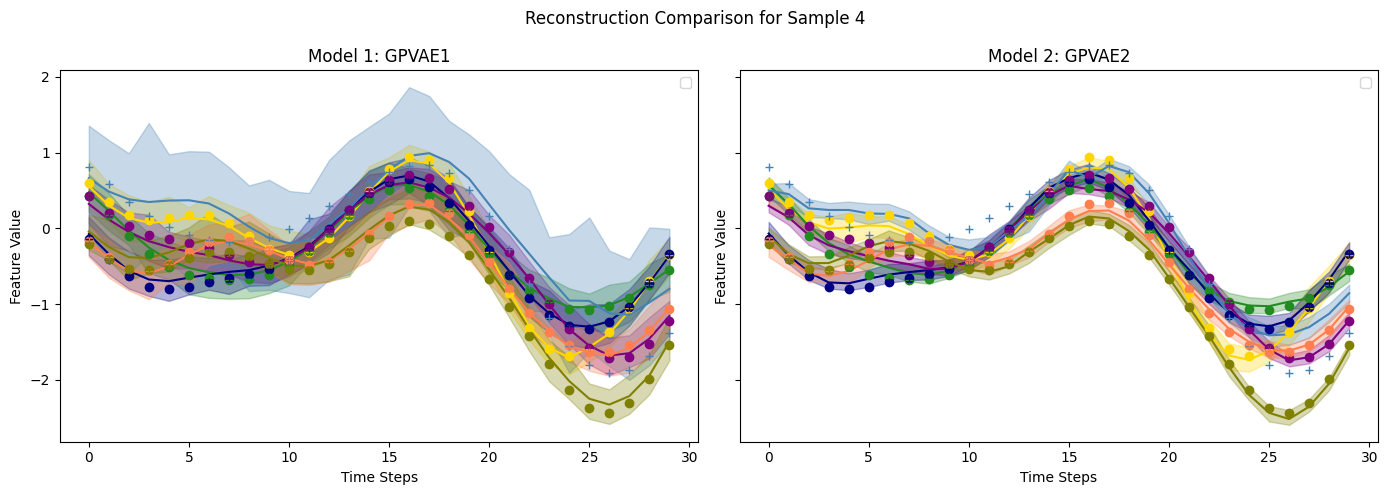

In [241]:
plot_recon_and_error_comparison(gpvae, gpvae2, X, X_normalized, i=4, n_samples=100)

## Evaluation of both methods


=== Evaluating Posterior Consistency ===

RMSE: 0.8834
NLL: 202339.2564
ELBO: -482673.6002

=== Evaluating GPVAE2 ===

RMSE: 0.7701
NLL: 150684.4614
ELBO: -1066196.0864


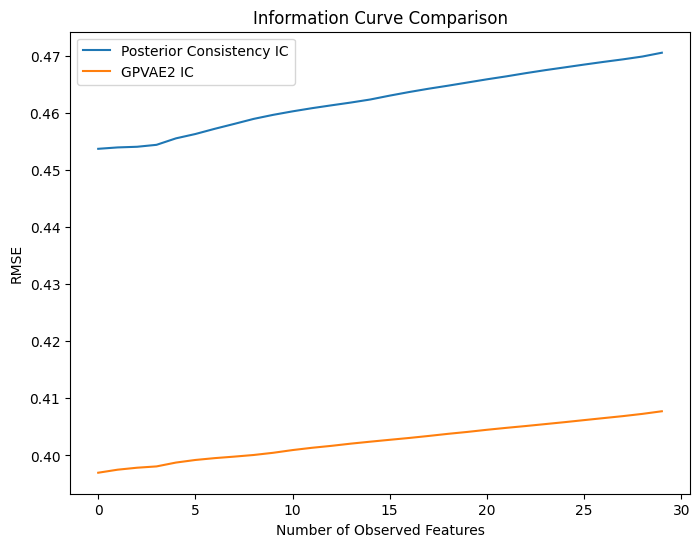

In [242]:
import numpy as np
import torch
import torch.distributions as dist
import matplotlib.pyplot as plt

# ==========================
# 🚀 Utility Functions
# ==========================

def compute_rmse(true_data, imputed_data, missing_mask):
    """
    Compute RMSE between imputed and true values, considering only missing values.
    """
    missing_values = missing_mask.astype(bool)
    mse = np.mean((true_data[missing_values] - imputed_data[missing_values]) ** 2)
    return np.sqrt(mse)

def compute_nll(recon_mu, recon_var, true_data, missing_mask):
    """
    Compute the Negative Log-Likelihood (NLL) for missing values.
    """
    missing_values = missing_mask.astype(bool)
    recon_var = np.clip(recon_var, 1e-6, None)  # Avoid division by zero
    nll = 0.5 * np.sum(
        (true_data[missing_values] - recon_mu[missing_values])**2 / recon_var[missing_values]
        + np.log(recon_var[missing_values]) + np.log(2 * np.pi)
    )
    return nll

def compute_kl_divergence(q_mu, q_var, p_mu=0, p_var=1):
    """
    Compute KL divergence between approximate posterior q(z|x) and prior p(z).
    """
    q_dist = dist.Normal(q_mu, torch.sqrt(q_var))
    p_dist = dist.Normal(p_mu, torch.sqrt(torch.tensor(p_var)))
    kl_div = torch.distributions.kl_divergence(q_dist, p_dist)
    return kl_div.sum().item()

def compute_information_curve(X_true, X_imputed, missing_mask):
    """
    Compute the Information Curve (IC) by iteratively adding the most informative feature.
    """
    n_features = X_true.shape[1]
    observed_mask = np.zeros_like(missing_mask, dtype=bool)
    info_curve = []

    for _ in range(n_features):
        best_feature = None
        best_rmse = float('inf')

        for feature in range(n_features):
            if observed_mask[:, feature].any():  # Skip if already observed
                continue

            temp_mask = observed_mask.copy()
            temp_mask[:, feature] = True

            rmse = compute_rmse(X_true, X_imputed, temp_mask)
            if rmse < best_rmse:
                best_rmse = rmse
                best_feature = feature

        observed_mask[:, best_feature] = True
        info_curve.append(best_rmse)

    return info_curve

# ==========================
# 🚀 Benchmarking Function
# ==========================

def benchmark_models(models, model_names, X, missing_mask):
    """
    Compare two models on RMSE, NLL, ELBO, and IC.
    
    Parameters:
    - models (list): List containing two trained models [gpvae, gpvae2].
    - model_names (list): List of model names for display.
    - X (numpy array): Input data (ground truth).
    - missing_mask (numpy array): Binary mask (1 = missing, 0 = observed).
    
    Returns:
    - Dictionary with evaluation results.
    """
    results = {}

    for i, model in enumerate(models):
        print(f"\n=== Evaluating {model_names[i]} ===\n")

        # Encode & Decode
        qz_x = model.model.backbone.encode(torch.tensor(X).float())
        z = qz_x.rsample()
        X_recon = model.model.backbone.decode(z).mean.detach().numpy()

        # Compute Metrics
        rmse = compute_rmse(X, X_recon, missing_mask)
        nll = compute_nll(X_recon, np.ones_like(X_recon) * 0.1, X, missing_mask)
        kl_div = compute_kl_divergence(qz_x.mean.detach(), qz_x.variance.detach())
        elbo = -nll - kl_div
        info_curve = compute_information_curve(X, X_recon, missing_mask)

        # Store Results
        results[model_names[i]] = {
            "RMSE": rmse,
            "NLL": nll,
            "ELBO": elbo,
            "Information Curve": info_curve
        }

        # Print Results
        print(f"RMSE: {rmse:.4f}")
        print(f"NLL: {nll:.4f}")
        print(f"ELBO: {elbo:.4f}")

    # ==========================
    # 🚀 Plot Information Curves
    # ==========================
    plt.figure(figsize=(8,6))
    for i, model_name in enumerate(model_names):
        plt.plot(results[model_name]["Information Curve"], label=f"{model_name} IC")
    
    plt.xlabel("Number of Observed Features")
    plt.ylabel("RMSE")
    plt.legend()
    plt.title("Information Curve Comparison")
    plt.show()

    return results

# ==========================
# 🚀 Run Benchmarking
# ==========================

# Define models and names
models = [gpvae, gpvae2]
model_names = ["Posterior Consistency", "GPVAE2"]

# Identify missing values
missing_mask = (X == 0)

# Run Benchmark
results = benchmark_models(models, model_names, X, missing_mask)



In [243]:
import torch
import numpy as np

def evaluate_model(model, X, X_mask):
    """
    Evaluate a model's performance on missing value imputation.
    
    Parameters:
        model: The trained model to evaluate.
        X: The dataset with missing values.
        X_mask: A binary mask indicating observed (1) and missing (0) values.
    
    Returns:
        RMSE, NLL (observed values), NLL (full dataset), and ELBO.
    """
    
    # Encode data
    qz_x = model.model.backbone.encode(torch.tensor(X).float())
    
    # Sample from the latent space
    z = qz_x.rsample()
    
    # Decode the latent variables to get reconstructions
    px_z = model.model.backbone.decode(z)
    
    # Extract mean and variance
    X_recon_mean = px_z.mean.detach().numpy()
    X_recon_var = px_z.variance.detach().numpy().clip(min=1e-6)  # Avoid log(0)
    
    # Compute RMSE (only over missing values)
    mask_complement = 1 - X_mask  # Inverted mask: 1 for missing, 0 for observed
    mse = ((X - X_recon_mean) ** 2) * mask_complement  # Squared error for missing values
    rmse = np.sqrt(mse.sum() / mask_complement.sum())  # RMSE over missing values

    # Compute Negative Log-Likelihood (NLL) over observed values
    nll_observed = 0.5 * (np.log(2 * np.pi * X_recon_var) + (X - X_recon_mean) ** 2 / X_recon_var)
    nll_observed = (nll_observed * X_mask).sum() / X_mask.sum()  # Average NLL over observed values

    # Compute Negative Log-Likelihood (NLL) over all values
    nll_full = 0.5 * (np.log(2 * np.pi * X_recon_var) + (X - X_recon_mean) ** 2 / X_recon_var)
    nll_full = nll_full.mean()  # Average over all data points

    # Compute ELBO: Since your model does not maximize ELBO directly, this is just for reference
    q_dist = torch.distributions.Normal(qz_x.mean, qz_x.variance.sqrt())
    p_dist = torch.distributions.Normal(torch.zeros_like(qz_x.mean), torch.ones_like(qz_x.mean))
    kl_div = torch.distributions.kl_divergence(q_dist, p_dist).mean().item()
    elbo = - (nll_observed + kl_div)  # ELBO definition

    print(f"\n=== Evaluating {model.__class__.__name__} ===\n")
    print(f"RMSE (Missing Values Only): {rmse:.4f}")
    print(f"NLL (Observed Values): {nll_observed:.4f}")
    print(f"NLL (Full Dataset): {nll_full:.4f}")
    print(f"ELBO (for reference): {elbo:.4f}")

    return rmse, nll_observed, nll_full, elbo


In [244]:
import torch
import numpy as np

def evaluate_model(model, X, X_mask):
    """
    Evaluate a model's performance on missing value imputation.
    
    Parameters:
        model: The trained model to evaluate.
        X: The dataset with missing values.
        X_mask: A binary mask indicating observed (1) and missing (0) values.
    
    Returns:
        Tuple containing:
        - RMSE (missing values)
        - RMSE (observed values)
        - NLL (missing values)
        - NLL (observed values)
        - ELBO (missing values)
        - ELBO (observed values)
    """

    # Encode data
    qz_x = model.model.backbone.encode(torch.tensor(X, dtype=torch.float32))

    # Sample from the latent space
    z = qz_x.rsample()

    # Decode the latent variables to get reconstructions
    px_z = model.model.backbone.decode(z)

    # Extract mean and variance
    X_recon_mean = px_z.mean.detach().numpy()
    X_recon_var = px_z.variance.detach().numpy().clip(min=1e-6)  # Avoid log(0)

    # Compute RMSE separately for missing & observed values
    mask_missing = 1 - X_mask  # 1 for missing, 0 for observed
    mask_observed = X_mask  # 1 for observed, 0 for missing

    mse_missing = ((X - X_recon_mean) ** 2) * mask_missing
    mse_observed = ((X - X_recon_mean) ** 2) * mask_observed

    # Handle cases where no missing values exist (to avoid division by zero)
    if mask_missing.sum() > 0:
        rmse_missing = np.sqrt(mse_missing.sum() / mask_missing.sum())
    else:
        rmse_missing = np.nan

    if mask_observed.sum() > 0:
        rmse_observed = np.sqrt(mse_observed.sum() / mask_observed.sum())
    else:
        rmse_observed = np.nan

    # Compute Negative Log-Likelihood (NLL) for missing & observed values
    nll = 0.5 * (np.log(2 * np.pi * X_recon_var) + (X - X_recon_mean) ** 2 / X_recon_var)

    nll_missing = (nll * mask_missing).sum() / mask_missing.sum() if mask_missing.sum() > 0 else np.nan
    nll_observed = (nll * mask_observed).sum() / mask_observed.sum() if mask_observed.sum() > 0 else np.nan

    # Compute ELBO for missing & observed values
    q_dist = torch.distributions.Normal(qz_x.mean, qz_x.variance.sqrt())
    p_dist = torch.distributions.Normal(torch.zeros_like(qz_x.mean), torch.ones_like(qz_x.mean))
    kl_div = torch.distributions.kl_divergence(q_dist, p_dist).mean().item()

    elbo_missing = -(nll_missing + kl_div) if not np.isnan(nll_missing) else np.nan
    elbo_observed = -(nll_observed + kl_div) if not np.isnan(nll_observed) else np.nan

    print(f"\n=== Evaluating {model.__class__.__name__} ===\n")
    print(f"RMSE (Missing): {rmse_missing:.4f}, RMSE (Observed): {rmse_observed:.4f}")
    print(f"NLL (Missing): {nll_missing:.4f}, NLL (Observed): {nll_observed:.4f}")
    print(f"ELBO (Missing): {elbo_missing:.4f}, ELBO (Observed): {elbo_observed:.4f}")

    return rmse_missing, rmse_observed, nll_missing, nll_observed, elbo_missing, elbo_observed


In [245]:
X_mask = (X!=0)
_ = evaluate_model(gpvae, X, X_mask)
_ = evaluate_model(gpvae2, X, X_mask)


=== Evaluating GP_VAE_posterior_concistency ===

RMSE (Missing): 0.8833, RMSE (Observed): 0.1497
NLL (Missing): 4.0494, NLL (Observed): -0.1605
ELBO (Missing): -4.6723, ELBO (Observed): -0.4624

=== Evaluating GP_VAE ===

RMSE (Missing): 0.7689, RMSE (Observed): 0.1196
NLL (Missing): 2.9991, NLL (Observed): -0.2056
ELBO (Missing): -5.0334, ELBO (Observed): -1.8287


In [224]:
X_mask = (X!=0)
rmse, nll_obs, nll_full, elbo = evaluate_model(gpvae, X, X_mask)
rmse2, nll_obs2, nll_full2, elbo2 = evaluate_model(gpvae2, X, X_mask)


=== Evaluating GP_VAE_posterior_concistency ===

RMSE (Missing Values Only): 0.9279
NLL (Observed Values): -0.1193
NLL (Full Dataset): 1.2650
ELBO (for reference): -0.4591

=== Evaluating GP_VAE ===

RMSE (Missing Values Only): 0.9773
NLL (Observed Values): -0.0051
NLL (Full Dataset): 1.5019
ELBO (for reference): -0.8491


## Observe sampled reconstructions

In [120]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_recon_and_error(gpvae, X, X_normalized, i = 9, n_samples = 50):
    # Encode input data
    qz_x = gpvae.model.backbone.encode(torch.tensor(X[:20]).float())
    
    # Generate multiple reconstructions
    reconstructions = []
    for _ in range(n_samples):
        z = qz_x.rsample()  # Sample latent variable
        X_recon = gpvae.model.backbone.decode(z).mean.detach().numpy()
        reconstructions.append(X_recon[i])
    
    # Convert to NumPy array for easier manipulation
    reconstructions = np.array(reconstructions)
    
    # Compute min and max for each feature (across the 50 reconstructions)
    recon_min = np.min(reconstructions, axis=0)
    recon_max = np.max(reconstructions, axis=0)
    
    # Compute mean reconstruction
    z = qz_x.mean
    X_recon_mean = gpvae.model.backbone.decode(z).mean.detach().numpy()[i]
    
    colors = ['gold','forestgreen','navy','purple','steelblue','coral','olive','rosybrown']
    
    for _ in range(recon_min.shape[1]):
        # Plot shaded uncertainty region (fill between min and max)
        plt.fill_between(range(len(X_recon_mean)), recon_min[:,_], recon_max[:,_], alpha=0.3, color = colors[_])
    
    for _ in range(recon_min.shape[1]):
    
        # Plot mean reconstruction
        plt.plot(X_recon_mean[:,_], color = colors[_])
    
        # Plot original input with missing values indicated
        X_0 = np.copy(X[i])
        X_0[X_0 == 0] = np.nan  # Mark missing values
        plt.plot(X_0[:,_], 'o', color = colors[_])
        
        # (Optional) Plot normalized input for reference
        plt.plot(X_normalized[i][:,_], '+', color = colors[_])
    
    # Final plot settings
    plt.legend()
    plt.xlabel("Feature Index")
    plt.ylabel("Value")
    plt.title(f"Reconstruction of Sample {i} with Uncertainty")
    plt.show()


In [158]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_recon_and_error_comparison(gpvae1, gpvae2, X, X_normalized, i=9, n_samples=50):
    """
    Plot the reconstruction of a given sample `i` for two models (gpvae1 & gpvae2).
    It visualizes the uncertainty by filling the region between min and max reconstructions.
    
    Parameters:
        gpvae1, gpvae2: The two models to compare
        X: Original input data
        X_normalized: Normalized input data
        i: Index of the sample to reconstruct
        n_samples: Number of samples for uncertainty estimation
    """
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey = True)  # Two side-by-side plots
    
    models = [gpvae1, gpvae2]
    titles = ["Model 1: GPVAE1", "Model 2: GPVAE2"]
    
    for ax, gpvae, title in zip(axes, models, titles):
        # Encode input data
        qz_x = gpvae.model.backbone.encode(torch.tensor(X[:20]).float())
        
        # Generate multiple reconstructions
        reconstructions = []
        for _ in range(n_samples):
            z = qz_x.rsample()  # Sample latent variable
            X_recon = gpvae.model.backbone.decode(z).mean.detach().numpy()
            reconstructions.append(X_recon[i])

        # Convert to NumPy array
        reconstructions = np.array(reconstructions)
        
        # Compute min and max for uncertainty visualization
        recon_min = np.min(reconstructions, axis=0)
        recon_max = np.max(reconstructions, axis=0)

        # Compute mean reconstruction
        z = qz_x.mean
        X_recon_mean = gpvae.model.backbone.decode(z).mean.detach().numpy()[i]

        # Define colors
        colors = ['gold','forestgreen','navy','purple','steelblue','coral','olive','rosybrown']
        
        # Plot shaded uncertainty region
        for feature_idx in range(recon_min.shape[1]):
            ax.fill_between(range(len(X_recon_mean)), 
                            recon_min[:, feature_idx], 
                            recon_max[:, feature_idx], 
                            alpha=0.3, color=colors[feature_idx])
        
        # Plot mean reconstruction
        for feature_idx in range(recon_min.shape[1]):
            ax.plot(X_recon_mean[:, feature_idx], color=colors[feature_idx]) #, label=f"Feature {feature_idx + 1}"
        
        # Plot original input with missing values indicated
        X_0 = np.copy(X[i])
        X_0[X_0 == 0] = np.nan  # Mark missing values
        for feature_idx in range(X_0.shape[1]):
            ax.plot(X_0[:, feature_idx], 'o', color=colors[feature_idx])

        # (Optional) Plot normalized input for reference
        for feature_idx in range(X_normalized.shape[2]):
            ax.plot(X_normalized[i][:, feature_idx], '+', color=colors[feature_idx])
        
        # Set labels and title
        ax.set_title(title)
        ax.set_xlabel("Time Steps")
        ax.set_ylabel("Feature Value")
        ax.legend()
    
    # Final layout adjustments
    plt.suptitle(f"Reconstruction Comparison for Sample {i}")
    plt.tight_layout()
    plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


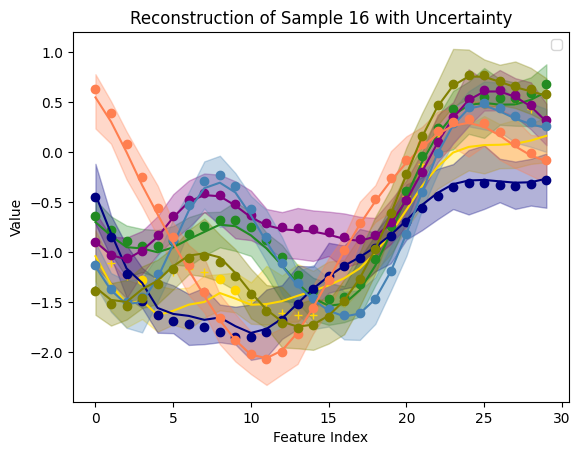

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


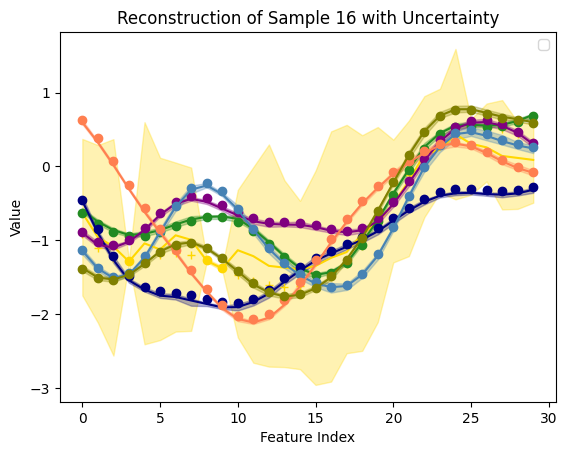

In [141]:

# Number of samples and index of the selected time series
n_samples = 50
i = 16
plot_recon_and_error(gpvae, X, X_normalized, i  = i)
plot_recon_and_error(gpvae2, X, X_normalized, i = i)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


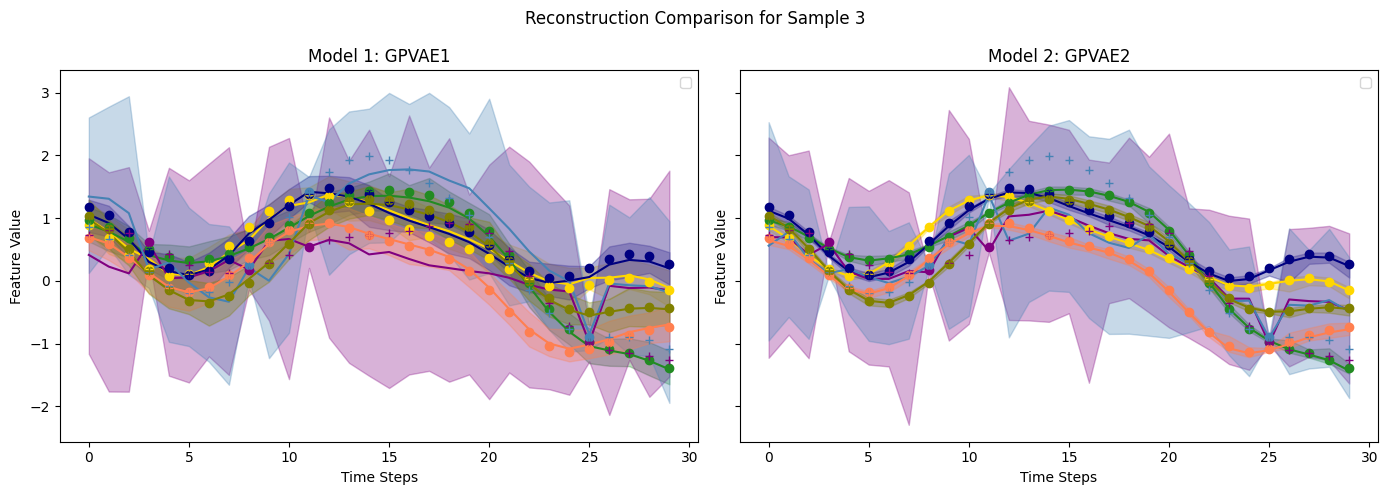

In [171]:
plot_recon_and_error_comparison(gpvae, gpvae2, X, X_normalized, i=3, n_samples=100)

In [87]:
from pypots.imputation.gp_ae.gp_model import ProbabilisticGP
#gpvae.gp = ProbabilisticGP(gpvae.model.backbone, assemble_data = gpvae._assemble_input_for_training, n_dims = n_new_dims, latent_size = latent_size)
#gpvae.gp.p = 0.1 # ratio of imputation of the dataset
gpvae.fit_kernel(dataset_train)  # train the model to learn the kernel parameters

fitting kernel


Epoch 1/20: 55it [00:01, 37.10it/s]


Epoch 1/20: Average Loss = 0.027182


Epoch 2/20: 55it [00:01, 37.15it/s]


Epoch 2/20: Average Loss = 0.026968


...

Epoch 6/20: Average Loss = 0.026984


Epoch 7/20: 55it [00:01, 42.01it/s]


Epoch 7/20: Average Loss = 0.026841


Epoch 8/20: 26it [00:00, 39.16it/s]


KeyboardInterrupt: 

## Visualisation: embed the first 10 time series, use the GP scheme to correct, and plot reconstruction

In [88]:
X_torch = torch.tensor(X).float()[:20]
embedding = gpvae.model.backbone.encode(X_torch)
imputed_data = gpvae.gp.infer(embedding, X_torch)
X_recon = gpvae.model.backbone.decode(embedding.mean).mean

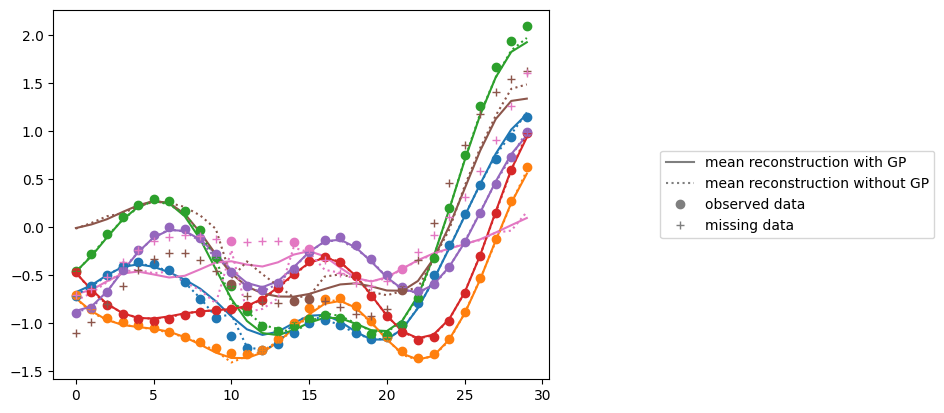

In [91]:
i = 6 ## reconstruct time series number i
X_torch[X_torch==0] = torch.nan
plt.plot(imputed_data[i].detach())
plt.plot([], label = 'mean reconstruction with GP')
plt.gca().set_prop_cycle(None)
plt.plot(X_recon[i].detach(), ':')
plt.plot([], ':', label = 'mean reconstruction without GP')
plt.gca().set_prop_cycle(None)
plt.plot(X_torch[i].detach(), 'o');
plt.plot([], 'o', label = 'observed data')
plt.gca().set_prop_cycle(None)
plt.plot(X_normalized[i], '+');
plt.plot([], '+', label = 'missing data')
plt.legend(bbox_to_anchor=[1.5, 0.5], 
           loc='center')